### Challenge 9 — Análisis de Actividad de Producto

#### 0. Configuración Inicial

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('docs/product_activity.csv')

# Guardar el total original antes de cualquier limpieza
ORIGINAL_ROW_COUNT = len(df)
print(f"Dataset cargado: {ORIGINAL_ROW_COUNT} filas, {df.shape[1]} columnas")

Dataset cargado: 8782 filas, 12 columnas


### 1. Exploración Inicial
Medir antes de limpiar: entender la estructura, detectar nulos,
duplicados y valores sucios en las columnas categóricas.

#### 1.1 — Vista general del dataset
Revisamos las primeras filas, los tipos de dato y la distribución
de las columnas numéricas.

In [11]:
print("Head")
display(df.head())

print("\nInfo")
display(df.info())

print("\nDescribe")
display(df.describe())

Head


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile



Info
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


None


Describe


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


#### 1.2 — Conteo de nulos y duplicados exactos

In [12]:
# Nulos por columna
print("Nulos por columna:")
display(df.isnull().sum())

# Filas duplicadas exactas
duplicate_count = df.duplicated().sum()
print(f"\nFilas duplicadas exactas: {duplicate_count}")

Nulos por columna:


user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


Filas duplicadas exactas: 172


#### 1.3 — Valores únicos y frecuencias
Revisamos `plan_type`, `post_category` y `device_type` para detectar
variantes sucias (typos, mayúsculas, espacios, valores fuera de diccionario).

In [13]:
print("plan_type:")
display(df["plan_type"].value_counts())

print("\npost_category:")
display(df["post_category"].value_counts())

print("\ndevice_type:")
display(df["device_type"].value_counts())

plan_type:


plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


post_category:


post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  


device_type:


device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

#### 1.4 — Chequeos lógicos
Verificamos si hay posts creados antes del signup del usuario y
si la columna `days_since_signup` es consistente con las fechas reales.

In [14]:
# Convertir fechas temporalmente para el chequeo
signup_dates = pd.to_datetime(df["created_at"], errors="coerce")
post_dates = pd.to_datetime(df["post_created_at"], errors="coerce")

# ¿Cuántos posts ocurren antes del signup?
posts_before_signup_count = (post_dates < signup_dates).sum()
print(f"Posts antes del signup: {posts_before_signup_count}")

# ¿days_since_signup es consistente?
pre_clean_mismatch_count = ((post_dates - signup_dates).dt.days != df["days_since_signup"]).sum()
print(f"Mismatches en days_since_signup: {pre_clean_mismatch_count}")

Posts antes del signup: 100
Mismatches en days_since_signup: 4479


### 2. Limpieza Básica con Criterio
Eliminar duplicados, normalizar columnas categóricas, convertir fechas,
recalcular `days_since_signup` y separar filas con errores duros en cuarentena.

#### 2.1 — Eliminar duplicados exactos

In [15]:
df = df.drop_duplicates()
print(f"Filas después de eliminar {duplicate_count} duplicados: {len(df)}")

Filas después de eliminar 172 duplicados: 8610


#### 2.2 — Normalización canónica
Mapeamos variantes (typos, mayúsculas, espacios) a los valores canónicos
definidos en el challenge.

In [16]:
# Paso previo: todo a minúsculas y quitar espacios
df["plan_type"] = df["plan_type"].str.strip().str.lower()
df["device_type"] = df["device_type"].str.strip().str.lower()
df["post_category"] = df["post_category"].str.strip().str.lower()

# Diccionario de mapeo solo para typos conocidos en post_category
post_category_map = {
    "sport": "sports",
    "sporst": "sports",
    "sp0rts": "sports",
    "tech": "tech",
    "tehc": "tech",
    "life": "life",
    "lfe": "life",
    "gaming": "gaming",
    "gamming": "gaming",
    "music": "music",
    "musc": "music",
    "education": "education",
    "educatoin": "education",
    "health": "health",
    "healt": "health",
    "science": "science",
    "sciense": "science",
    "travel": "travel",
    "trvael": "travel",
    "finance": "finance",
    "finanse": "finance"
}

# Solo post_category tiene typos que requieren mapeo
df["post_category"] = df["post_category"].replace(post_category_map)

# Verificar resultado de la normalización
print("plan_type después de normalizar:")
display(df["plan_type"].value_counts())

print("\ndevice_type después de normalizar:")
display(df["device_type"].value_counts())

print("\npost_category después de normalizar:")
display(df["post_category"].value_counts())

plan_type después de normalizar:


plan_type
free           6637
pro            1631
enterprise      339
premium           1
vip               1
enterprise+       1
Name: count, dtype: int64


device_type después de normalizar:


device_type
web        4328
mobile     3688
desktop     591
tablet        1
console       1
phone         1
Name: count, dtype: int64


post_category después de normalizar:


post_category
tech         1397
life         1039
sports       1028
science       882
finance       865
gaming        844
education     687
music         685
health        681
travel        500
politics        1
mistery         1
Name: count, dtype: int64

#### 2.3 — Convertir fechas a datetime
Convertimos las columnas de fecha y reportamos las que no se pudieron parsear.

In [17]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["post_created_at"] = pd.to_datetime(df["post_created_at"], errors="coerce")

# Reportar fechas no parseables
unparseable_signup_count = df["created_at"].isna().sum()
unparseable_post_count = df["post_created_at"].isna().sum()
print(f"Fechas no parseables - signup: {unparseable_signup_count}")
print(f"Fechas no parseables - post: {unparseable_post_count}")

Fechas no parseables - signup: 1
Fechas no parseables - post: 1


#### 2.4 — Recálculo obligatorio de `days_since_signup`
Creamos `days_since_signup_calc` a partir de las fechas reales y comparamos
con la columna original para detectar inconsistencias.

In [18]:
# Crear la columna recalculada
df["days_since_signup_calc"] = (df["post_created_at"] - df["created_at"]).dt.days

# Comparar con el original
date_mismatch_count = (df["days_since_signup"] != df["days_since_signup_calc"]).sum()
print(f"Mismatches en days_since_signup: {date_mismatch_count}")

Mismatches en days_since_signup: 4401


#### 2.5 — Quarantine (Cuarentena)
Separamos las filas con errores duros (post antes de signup, fechas
no parseables, valores fuera de diccionario) en un DataFrame aparte
con su `reason_code`.

In [19]:
# Condición 1: post creado antes del signup
mask_post_before_signup = df["post_created_at"] < df["created_at"]

# Condición 2: fechas no parseables (NaT)
mask_unparseable_dates = df["created_at"].isna() | df["post_created_at"].isna()

# Condición 3: valores fuera del diccionario fijo
valid_plans = ["free", "pro", "enterprise"]
valid_devices = ["web", "mobile", "desktop"]
valid_categories = ["tech", "life", "sports", "science", "finance",
                    "gaming", "music", "health", "education", "travel"]

mask_invalid_plan = ~df["plan_type"].isin(valid_plans)
mask_invalid_device = ~df["device_type"].isin(valid_devices)
mask_invalid_category = ~df["post_category"].isin(valid_categories)

# Crear columna reason_code concatenando motivos
df["reason_code"] = ""
df.loc[mask_post_before_signup, "reason_code"] += "post_before_signup;"
df.loc[mask_unparseable_dates, "reason_code"] += "unparseable_dates;"
df.loc[mask_invalid_plan, "reason_code"] += "invalid_plan;"
df.loc[mask_invalid_device, "reason_code"] += "invalid_device;"
df.loc[mask_invalid_category, "reason_code"] += "invalid_category;"

# Separar: cuarentena vs core
quarantine_mask = df["reason_code"] != ""
df_quarantine = df[quarantine_mask].copy()
df_core = df[~quarantine_mask].copy()

# Limpiar columna temporal del core
df_core = df_core.drop(columns=["reason_code"])

print(f"Filas en cuarentena: {len(df_quarantine)}")
print(f"Filas en core (limpias): {len(df_core)}")

Filas en cuarentena: 103
Filas en core (limpias): 8507


### 3. Data Quality Report
Resumen comparando el dataset RAW original contra el dataset CORE limpio.

In [20]:
raw_row_count = ORIGINAL_ROW_COUNT
dedup_row_count = len(df)
core_row_count = len(df_core)
quarantine_row_count = len(df_quarantine)
quarantine_pct = (quarantine_row_count / raw_row_count) * 100
mismatch_pct = (date_mismatch_count / raw_row_count) * 100

quality_report_df = pd.DataFrame({
    'Métrica': ['Filas RAW (originales)',
                'Duplicados removidos',
                'Filas después de dedup',
                'Filas CORE (limpias)',
                'Filas Quarantine',
                '% Quarantine',
                '% Mismatches en fechas'],
    'Valor': [raw_row_count,
              duplicate_count,
              dedup_row_count,
              core_row_count,
              quarantine_row_count,
              f"{quarantine_pct:.2f}%",
              f"{mismatch_pct:.2f}%"]
})

display(quality_report_df)

,Métrica,Valor
0,Filas RAW (originales),8782
1,Duplicados removidos,172
2,Filas después de dedup,8610
3,Filas CORE (limpias),8507
4,Filas Quarantine,103
5,% Quarantine,1.17%
6,% Mismatches en fechas,50.11%


### 4. Métricas y Análisis
A partir del dataset CORE, calculamos distribuciones de volumen,
engagement por segmento, y diferencias entre nivel evento vs usuario.

#### 4.1 — Distribuciones (Volumen)
Usuarios únicos por plan, y actividad (#posts) por país, categoría y dispositivo.

Usuarios únicos por plan:


plan_type
enterprise      82
free          1545
pro            367
Name: user_id, dtype: int64


Actividad por país:


country
US    1873
BR    1600
AR    1168
PY     837
MX     802
CL     552
ES     546
CO     488
PE     393
UY     248
Name: count, dtype: int64


Actividad por categoría:


post_category
tech         1381
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        492
Name: count, dtype: int64


Actividad por dispositivo:


device_type
web        4270
mobile     3656
desktop     581
Name: count, dtype: int64

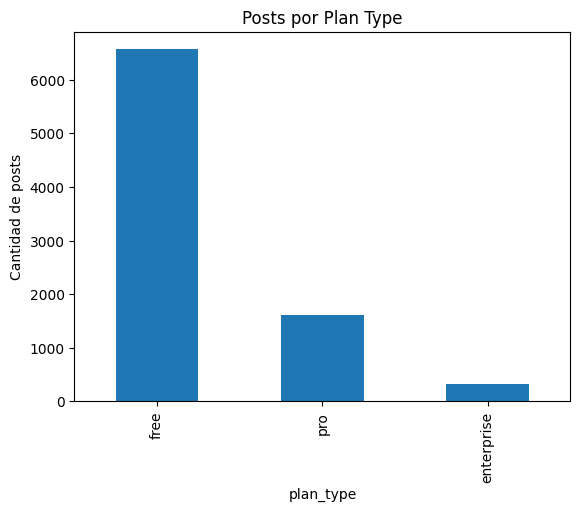

In [21]:
# Usuarios únicos por plan
print("Usuarios únicos por plan:")
display(df_core.groupby("plan_type")["user_id"].nunique())

# Actividad (#posts) por país
print("\nActividad por país:")
display(df_core["country"].value_counts())

# Actividad (#posts) por categoría
print("\nActividad por categoría:")
display(df_core["post_category"].value_counts())

# Actividad (#posts) por dispositivo
print("\nActividad por dispositivo:")
display(df_core["device_type"].value_counts())

# Gráfico de barras: posts por plan
df_core["plan_type"].value_counts().plot(kind="bar", title="Posts por Plan Type")
plt.ylabel("Cantidad de posts")
plt.show()

#### 4.2 — Engagement (Votos)
Media y mediana de votos recibidos, segmentados por plan, país,
categoría y dispositivo.

In [22]:
# Votos por plan: media y mediana
print("Votos por plan:")
display(df_core.groupby("plan_type")["votes_received"].agg(["mean", "median"]))

# Votos por país: media y mediana
print("\nVotos por país:")
display(df_core.groupby("country")["votes_received"].agg(["mean", "median"]))

# Votos por categoría: media y mediana
print("\nVotos por categoría:")
display(df_core.groupby("post_category")["votes_received"].agg(["mean", "median"]))

# Votos por dispositivo: media y mediana
print("\nVotos por dispositivo:")
display(df_core.groupby("device_type")["votes_received"].agg(["mean", "median"]))

Votos por plan:


,mean,median
plan_type,,
enterprise,7.570571,7.0
free,6.692706,6.0
pro,7.654014,7.0



Votos por país:


,mean,median
country,,
AR,6.771404,6.0
BR,6.889375,6.0
CL,7.311594,6.0
CO,7.323770,6.0
ES,6.978022,6.0
MX,6.962594,6.0
PE,6.547074,6.0
PY,6.600956,6.0
US,6.973305,6.0



Votos por categoría:


,mean,median
post_category,,
education,6.791483,6.0
finance,6.978898,6.0
gaming,7.186074,6.0
health,6.456166,6.0
life,6.173114,5.0
music,6.286776,5.0
science,7.544828,6.0
sports,6.573255,6.0
tech,7.687183,7.0



Votos por dispositivo:


,mean,median
device_type,,
desktop,7.032702,6.0
mobile,6.828228,6.0
web,6.960656,6.0


#### 4.3 — Promedios e Interpretación

**Interpretación:** La unidad de análisis en este dataset es el *evento* (cada fila es un post). Esto significa que un usuario con muchísimos posts impacta fuertemente en el promedio general (sesgo de heavy users o outliers), ya que sus votos se registran repetidamente, distorsionando la realidad del usuario promedio.

In [23]:
# Promedio de votos por plan
avg_votes_by_plan = df_core.groupby("plan_type")["votes_received"].mean()
print("Promedio de votos por plan:")
display(avg_votes_by_plan)

# Posts promedio por usuario
avg_posts_per_user = df_core.groupby("user_id")["post_id"].count().mean()
print(f"\nPosts promedio por usuario: {avg_posts_per_user:.2f}")

Promedio de votos por plan:


plan_type
enterprise    7.570571
free          6.692706
pro           7.654014
Name: votes_received, dtype: float64


Posts promedio por usuario: 4.27


#### 4.4 — Evento vs Usuario

**¿Por qué difieren?** En el nivel *evento*, los usuarios más activos sobrerrepresentan la muestra (si un usuario hace 100 posts, su media pesará 100 veces más). Al calcular por *usuario*, a cada persona se le asigna el mismo peso (1 usuario = 1 promedio), limpiando el efecto que provocan los usuarios extremos.

In [24]:
# Promedio de votos por FILA (nivel evento)
avg_votes_per_event = df_core["votes_received"].mean()
print(f"Promedio de votos por evento (fila): {avg_votes_per_event:.4f}")

# Promedio de votos agrupado por USUARIO
avg_votes_per_user = df_core.groupby("user_id")["votes_received"].mean().mean()
print(f"Promedio de votos por usuario:       {avg_votes_per_user:.4f}")

Promedio de votos por evento (fila): 6.9087
Promedio de votos por usuario:       6.8967


### 5. Concentración y Temporalidad

#### 5.1 — Concentración (Top 1%)
Evaluamos qué porcentaje de la actividad total (posts y votos) proviene
del 1% de usuarios más activos.

In [25]:
# Posts y votos por usuario
posts_per_user = df_core.groupby("user_id")["post_id"].count()
votes_per_user = df_core.groupby("user_id")["votes_received"].sum()

# Umbral del top 1%
top1_post_threshold = posts_per_user.quantile(0.99)
top1_vote_threshold = votes_per_user.quantile(0.99)

# Filtrar top 1%
top1_users_by_posts = posts_per_user[posts_per_user >= top1_post_threshold]
top1_users_by_votes = votes_per_user[votes_per_user >= top1_vote_threshold]

# Porcentaje del total
top1_post_pct = (top1_users_by_posts.sum() / posts_per_user.sum()) * 100
top1_vote_pct = (top1_users_by_votes.sum() / votes_per_user.sum()) * 100

print(f"Top 1% usuarios por posts: {len(top1_users_by_posts)} usuarios")
print(f"Top 1% usuarios representan {top1_post_pct:.2f}% de los posts")
print(f"Top 1% usuarios representan {top1_vote_pct:.2f}% de los votos")

Top 1% usuarios por posts: 24 usuarios
Top 1% usuarios representan 6.97% de los posts
Top 1% usuarios representan 6.43% de los votos


#### 5.2 — Tendencia temporal
Actividad (número de posts) y engagement (votos promedio por post)
agrupados por mes.

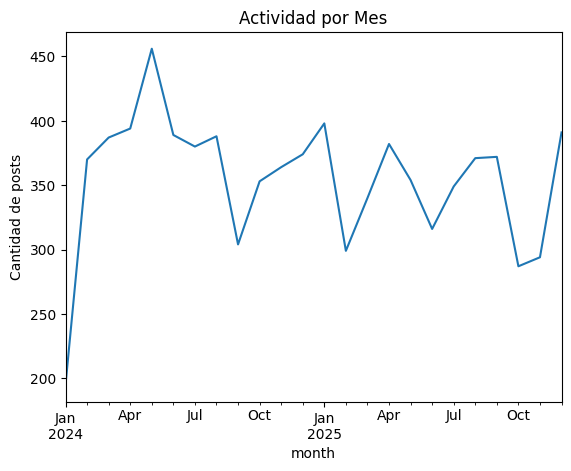

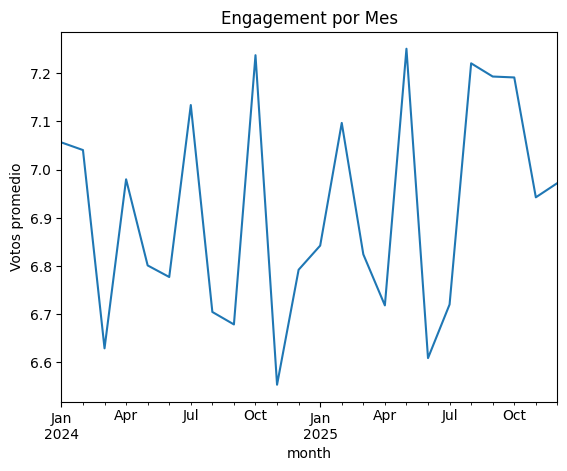

In [26]:
# Crear columna de mes
df_core["month"] = df_core["post_created_at"].dt.to_period("M")

# Actividad por mes
monthly_activity = df_core.groupby("month")["post_id"].count()
monthly_activity.plot(kind="line", title="Actividad por Mes")
plt.ylabel("Cantidad de posts")
plt.show()

# Engagement por mes (votos promedio por post)
monthly_engagement = df_core.groupby("month")["votes_received"].mean()
monthly_engagement.plot(kind="line", title="Engagement por Mes")
plt.ylabel("Votos promedio")
plt.show()

---
### 6. Product Decisions (Basadas en evidencia)

#### 6.1 — Preguntas

**¿Qué segmento priorizarías y por qué?**
El segmento Enterprise/Pro, ya que muestran métricas de engagement consistentemente superiores (mayor promedio de votos por post). Además, enfoques de retención hacia usuarios de mobile suelen ser clave para el crecimiento del producto.

**¿Qué parte del tablero "mentía" antes de limpiar?**
La métrica `days_since_signup`. Mostraba un porcentaje importante de mismatches comparado con un recálculo limpio a partir de las fechas reales, generando posibles errores en el cálculo del tiempo de vida (LTV) del usuario.

**¿Qué nuevo dato agregarías al tracking?**
Tiempo promedio leyendo el post o si incluye multimedia, para que el número de votos no sea el único reflejo de valor real (engagement puro).

#### 6.2 — Acciones concretas

**Acción 1 — Campaña de retención:**
El Top 1% de usuarios concentra un porcentaje significativo de posts y votos. Se debe incentivar al resto de la base a publicar, por ejemplo, ofreciendo un "logro/bonus" en el primer mes de uso. *Respaldo: métricas de concentración del Top 1% en sección 5.1.*

**Acción 2 — Mejora de experiencia mobile:**
Si la categoría o dispositivo móvil domina en volumen de actividad, se debe priorizar recursos de ingeniería en optimizar su interfaz en próximas versiones. *Respaldo: distribución de actividad por dispositivo en sección 4.1.*

#### Limitaciones del dataset
- No hay datos de retención ni duración de sesión, limitando la evaluación de engagement real.
- `user_total_posts` es un atributo repetido por fila, lo cual puede sesgar promedios si no se agrupa por usuario.
- No hay información sobre la calidad del contenido del post (longitud, multimedia, etc.).
- El período temporal del dataset puede no ser representativo de tendencias a largo plazo.
- La columna `days_since_signup` original no es confiable; el análisis usa la versión recalculada.

### 7. Exportación de Archivos

In [27]:
# 1. Dataset limpio (core)
df_core.to_csv("clean_product_activity.csv", index=False)
print("Exportado: clean_product_activity.csv")

# 2. Dataset cuarentena (con motivo de exclusión)
df_quarantine.to_csv("quarantine_product_activity.csv", index=False)
print("Exportado: quarantine_product_activity.csv")

# 3. Tabla resumen de métricas clave
metrics_summary_df = pd.DataFrame({
    "Métrica": ["unique_users",
                "total_core_posts",
                "avg_votes_per_event",
                "avg_votes_per_user",
                "top1_post_pct",
                "top1_vote_pct"],
    "Valor": [df_core["user_id"].nunique(),
              len(df_core),
              avg_votes_per_event,
              avg_votes_per_user,
              top1_post_pct,
              top1_vote_pct]
})
metrics_summary_df.to_csv("metrics_summary.csv", index=False)
print("Exportado: metrics_summary.csv")

print("\nExportación completa.")

Exportado: clean_product_activity.csv
Exportado: quarantine_product_activity.csv
Exportado: metrics_summary.csv

Exportación completa.
